In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
plt.rc('font', family = 'Malgun Gothic')

In [138]:
# 데이터를 이렇게 처음부터 여러개 불러오는건 처음이다. >> 나중에 보니, 연도만 다르고 형식이 같아서 처음부터 연도칼럼 생성해서 자료 합치는게 더 쉬웠을듯
df18 = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\경찰청_범죄 발생 지역별 통계_20181231.csv", encoding = 'euc-kr')
df19 = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\경찰청_범죄 발생 지역별 통계_20191231.csv", encoding = 'euc-kr')
df20 = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\경찰청_범죄 발생 지역별 통계_20201231.csv", encoding = 'euc-kr')
df21 = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\경찰청_범죄 발생 지역별 통계_20211231.csv", encoding = 'euc-kr')
df22 = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\경찰청_범죄 발생 지역별 통계_20221231.csv", encoding = 'euc-kr')

In [139]:
df21.head()

,범죄대분류,범죄중분류,서울,부산,대구,인천,광주,대전,울산,세종,...,경남 밀양,경남 사천,경남 양산,경남 진주,경남 창원,경남 통영,제주 서귀포,제주 제주,기타도시,도시이외
0,강력범죄,살인기수,47,15,11,21,5,11,8,1,...,1,2,1,3,3,1,2,4,2,29
1,강력범죄,살인미수등,76,30,13,21,4,8,7,3,...,0,1,2,3,8,0,1,11,1,30
2,강력범죄,강도,122,51,23,34,13,9,10,1,...,0,0,4,11,5,0,4,8,1,29
3,강력범죄,강간,1134,321,220,345,148,164,120,22,...,7,11,17,23,87,7,23,89,13,298
4,강력범죄,유사강간,180,55,33,56,24,27,18,4,...,0,3,2,3,13,5,7,12,0,48


In [140]:
# 범죄대분류가 어떤종류가 있는지 value_counts() & sort_values로 확인
df20['범죄대분류'].value_counts().sort_values(ascending = False)

범죄대분류
지능범죄      9
폭력범죄      8
강력범죄      8
풍속범죄      2
절도범죄      1
특별경제범죄    1
마약범죄      1
보건범죄      1
환경범죄      1
교통범죄      1
노동범죄      1
안보범죄      1
선거범죄      1
병역범죄      1
기타범죄      1
Name: count, dtype: int64

In [141]:
# 결측값 유무 확인
df18.isnull().sum()

범죄대분류     4
범죄중분류     4
서울        4
부산        3
대구        4
         ..
경남 통영     4
제주 서귀포    4
제주 제주     4
기타도시      4
도시이외      4
Length: 89, dtype: int64

In [142]:
# 공백값() 유무 확인
(df18 == ' ').sum()

범죄대분류     0
범죄중분류     0
서울        0
부산        1
대구        0
         ..
경남 통영     0
제주 서귀포    0
제주 제주     0
기타도시      0
도시이외      0
Length: 89, dtype: int64

In [143]:
# 공백과 결측을 0으로 변환하고 빈칸은 영어로 대체 (이건외워기)
df18 = df18.fillna(0).replace({' ':0})
df19 = df19.fillna(0).replace({' ':0})
df20 = df20.fillna(0).replace({' ':0})
df21 = df21.fillna(0).replace({' ':0})
df22 = df22.fillna(0).replace({' ':0})

In [144]:
# 지금자료안에 float (2.0). int(2), str (글자)까지 다 섞여있어 통일이 필요하다
for col in df18.columns[2:]: 
    df18[col] = df18[col].astype(int)
    df19[col] = df19[col].astype(int)
    df20[col] = df20[col].astype(int)
    df21[col] = df21[col].astype(int)
    df22[col] = df22[col].astype(int)

In [145]:
# 위에 내용에서 왜 [2:]를 썼는지 이해필요 0~1은 범죄대/중분류라 str이고, 2 부터 int로 변환해주는작업진행함
df18.columns[2:]

Index(['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기 고양', '경기 과천',
       '경기 광명', '경기 광주', '경기 구리', '경기 군포', '경기 김포', '경기 남양주', '경기 동두천',
       '경기 부천', '경기 성남', '경기 수원', '경기 시흥', '경기 안산', '경기 안성', '경기 안양', '경기 양주',
       '경기 여주', '경기 오산', '경기 용인', '경기 의왕', '경기 의정부', '경기 이천', '경기 파주', '경기 평택',
       '경기 포천', '경기 하남', '경기 화성', '강원 강릉', '강원 동해', '강원 삼척', '강원 속초', '강원 원주',
       '강원 춘천', '강원 태백', '충북 제천', '충북 청주', '충북 충주', '충남 계룡', '충남 공주', '충남 논산',
       '충남 당진', '충남 보령', '충남 서산', '충남 아산', '충남 천안', '전북 군산', '전북 김제', '전북 남원',
       '전북 익산', '전북 전주', '전북 정읍', '전남 광양', '전남 나주', '전남 목포', '전남 순천', '전남 여수',
       '경북 경산', '경북 경주', '경북 구미', '경북 김천', '경북 문경', '경북 상주', '경북 안동', '경북 영주',
       '경북 영천', '경북 포항', '경남 거제', '경남 김해', '경남 밀양', '경남 사천', '경남 양산', '경남 진주',
       '경남 창원', '경남 통영', '제주 서귀포', '제주 제주', '기타도시', '도시이외'],
      dtype='object')

In [174]:
# Q1. 2018 ~ 22년 각 지역별 사기범죄 추세를 시각화
regions = ['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종'] # 대상지역
result = pd.concat([df18.loc[df18['범죄중분류'] == '사기', regions], # 각 년도의 범죄중분류가 사기인 케이스들중 대상지역인 케이스만 추출하여 행 방향으로 합쳐 
                    df19.loc[df19['범죄중분류'] == '사기', regions],
                    df20.loc[df20['범죄중분류'] == '사기', regions],
                    df21.loc[df21['범죄중분류'] == '사기', regions],
                    df22.loc[df22['범죄중분류'] == '사기', regions]],
                    axis = 0, ignore_index = True)

In [175]:
df18.loc[df18['범죄중분류'] == '사기', regions]

,서울,부산,대구,인천,광주,대전,울산,세종
23,54270,22724,12040,15130,7084,7938,6233,1040


In [148]:
result

,서울,부산,대구,인천,광주,대전,울산,세종
0,54270,22724,12040,15130,7084,7938,6233,1040
1,57563,26061,14852,16201,7654,9171,6786,1352
2,62317,31488,16730,19258,8613,10368,7492,1540
3,48352,25516,15076,14870,7275,9063,6073,1117
4,52034,26847,14836,16652,8249,11734,5615,1528


In [149]:
result.astype(int)

,서울,부산,대구,인천,광주,대전,울산,세종
0,54270,22724,12040,15130,7084,7938,6233,1040
1,57563,26061,14852,16201,7654,9171,6786,1352
2,62317,31488,16730,19258,8613,10368,7492,1540
3,48352,25516,15076,14870,7275,9063,6073,1117
4,52034,26847,14836,16652,8249,11734,5615,1528


In [150]:
# 인덱스를 연도로 생성해줘야 해석 수월하다
result.index = [2018, 2019, 2020, 2021, 2022] # 여기는 '' 필요없네?

<Axes: xlabel='연도', ylabel='사기범죄수'>

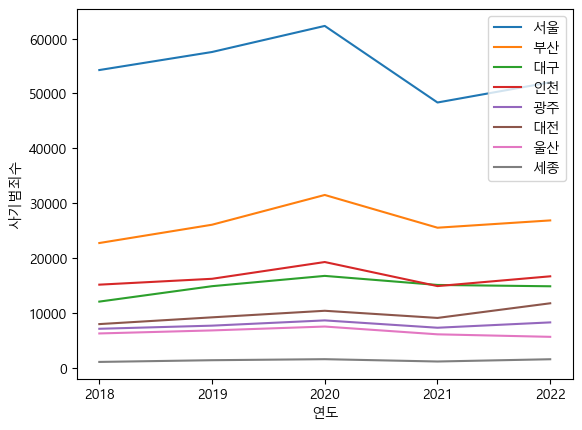

In [151]:
# 추세이니 선 그래프 (defalt) 보통 사용한다
result.plot(xticks = [2018, 2019, 2020, 2021, 2022], ylabel = '사기범죄수', xlabel = '연도') # xticks를 설정안했으면, 2018.0 처럼 숫자로 인식함

<Axes: title={'center': '경기도 강력범죄추세'}, xlabel='연도', ylabel='강력 범죄 건수'>

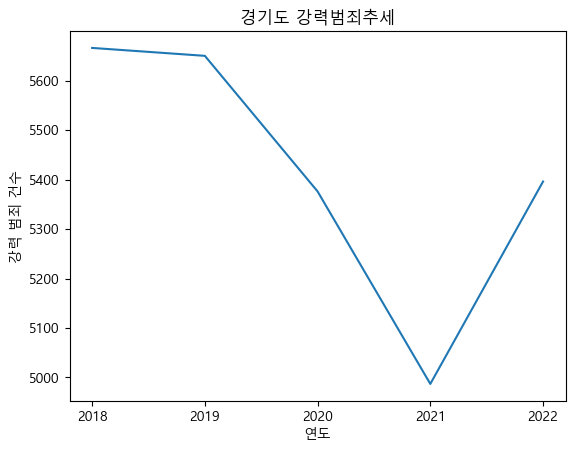

In [152]:
# Q2. 2018 ~ 22년 경기도 발생한 강력범죄 추세
# Raw 칼럼을 확인하면, 경기 고양, 경기 과천등으로 표기되어있어 '경기' 라는 단어가 들어가면 묶어줘야한다.
gyeonggi_cols = [col for col in df18.columns if col.startswith('경기')] # 처음에 있는 col의 의미는 경기들어가있는 칼럼을 찾으면 col 그래도 가져와라
data = []
for df in [df18, df19, df20, df21, df22]:
    data.append(df.loc[df['범죄대분류'] == '강력범죄', gyeonggi_cols].sum().sum()) # 지역별 Sum + 경기로 묶어서 Sum

# 위 데이터는 5개로 이뤄질것이고 5개년을 순회하니, 년도 index필요
data = pd.Series(data, index = [2018, 2019, 2020, 2021, 2022])
data.plot(xticks = [2018, 2019, 2020, 2021, 2022], ylabel = '강력 범죄 건수',
          title = '경기도 강력범죄추세', xlabel = '연도')

In [71]:
#Q3. 전체범죄 건수가 매년 감소한 지역의 범죄발생 건수 추이를 시각화하세요.

In [153]:
# 각 연도별로 지역별 범죄 건수
num_crime18 = df18.iloc[:, 2:].sum() # 행은 다 가져오고, 열은 두번째부터
num_crime19 = df19.iloc[:, 2:].sum()
num_crime20 = df20.iloc[:, 2:].sum()
num_crime21 = df21.iloc[:, 2:].sum()
num_crime22 = df22.iloc[:, 2:].sum()

num_crimes = pd.concat([num_crime18, num_crime19, num_crime20, num_crime21, num_crime22], axis = 1)

In [154]:
# 컬럼명 추가
num_crimes.columns = [2018, 2019, 2020, 2021, 2022]

In [158]:
num_crimes.head()

,2018,2019,2020,2021,2022
서울,306661,305909,290816,252289,267778
부산,115727,119267,120095,105737,112080
대구,72270,75707,72171,67795,66441
인천,88228,93347,91257,80589,84888
광주,43515,44102,43179,39203,38408


In [89]:
# 매년 범죄가 줄어드는것을 매년마다 열 방향으로 빼주는것으로도 할수 있지만, 코드가 더러워진다.
# 그래서 diff(axis = 1)을 사용하여
change_crimes = num_crimes.diff(axis = 1).iloc[:, 1:] # 행은 다 가져오고, 열은 1부터 즉 0값은 빼고 계산 or .drop(2018, axis = 1)써도된다.

In [170]:
#확인작업!
num_crimes.diff(axis = 1).iloc[:, 1:] # year별로 차가 전부 음수값이면 계속 감소했다고 정의

,2019,2020,2021,2022
서울,-752,-15093,-38527,15489
부산,3540,828,-14358,6343
대구,3437,-3536,-4376,-1354
인천,5119,-2090,-10668,4299
광주,587,-923,-3976,-795
...,...,...,...,...
경남 통영,887,-1591,-472,1907
제주 서귀포,-157,685,-1130,483
제주 제주,-1679,373,-1619,371
기타도시,4863,6960,2112,18501


In [176]:
# 결과값이 제대로 나왔다면 항상 음수가 되어야한다. (매년감소) > 0보다 큰것을 골라 다 합한게 0이면 전체숫자가 음수라는 접근법으로 풀었다
temp = (change_crimes > 0).sum(axis = 1) == 0
temp.loc[temp].index
# 결과값이 제대로 나왔다면 몇개 지역만 나왔을거다

Index(['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기 고양', '경기 과천',
       '경기 광명', '경기 광주', '경기 구리', '경기 군포', '경기 김포', '경기 남양주', '경기 동두천',
       '경기 부천', '경기 성남', '경기 수원', '경기 시흥', '경기 안산', '경기 안성', '경기 안양', '경기 양주',
       '경기 여주', '경기 오산', '경기 용인', '경기 의왕', '경기 의정부', '경기 이천', '경기 파주', '경기 평택',
       '경기 포천', '경기 하남', '경기 화성', '강원 강릉', '강원 동해', '강원 삼척', '강원 속초', '강원 원주',
       '강원 춘천', '강원 태백', '충북 제천', '충북 청주', '충북 충주', '충남 계룡', '충남 공주', '충남 논산',
       '충남 당진', '충남 보령', '충남 서산', '충남 아산', '충남 천안', '전북 군산', '전북 김제', '전북 남원',
       '전북 익산', '전북 전주', '전북 정읍', '전남 광양', '전남 나주', '전남 목포', '전남 순천', '전남 여수',
       '경북 경산', '경북 경주', '경북 구미', '경북 김천', '경북 문경', '경북 상주', '경북 안동', '경북 영주',
       '경북 영천', '경북 포항', '경남 거제', '경남 김해', '경남 밀양', '경남 사천', '경남 양산', '경남 진주',
       '경남 창원', '경남 통영', '제주 서귀포', '제주 제주', '기타도시', '도시이외'],
      dtype='object')

<Axes: >

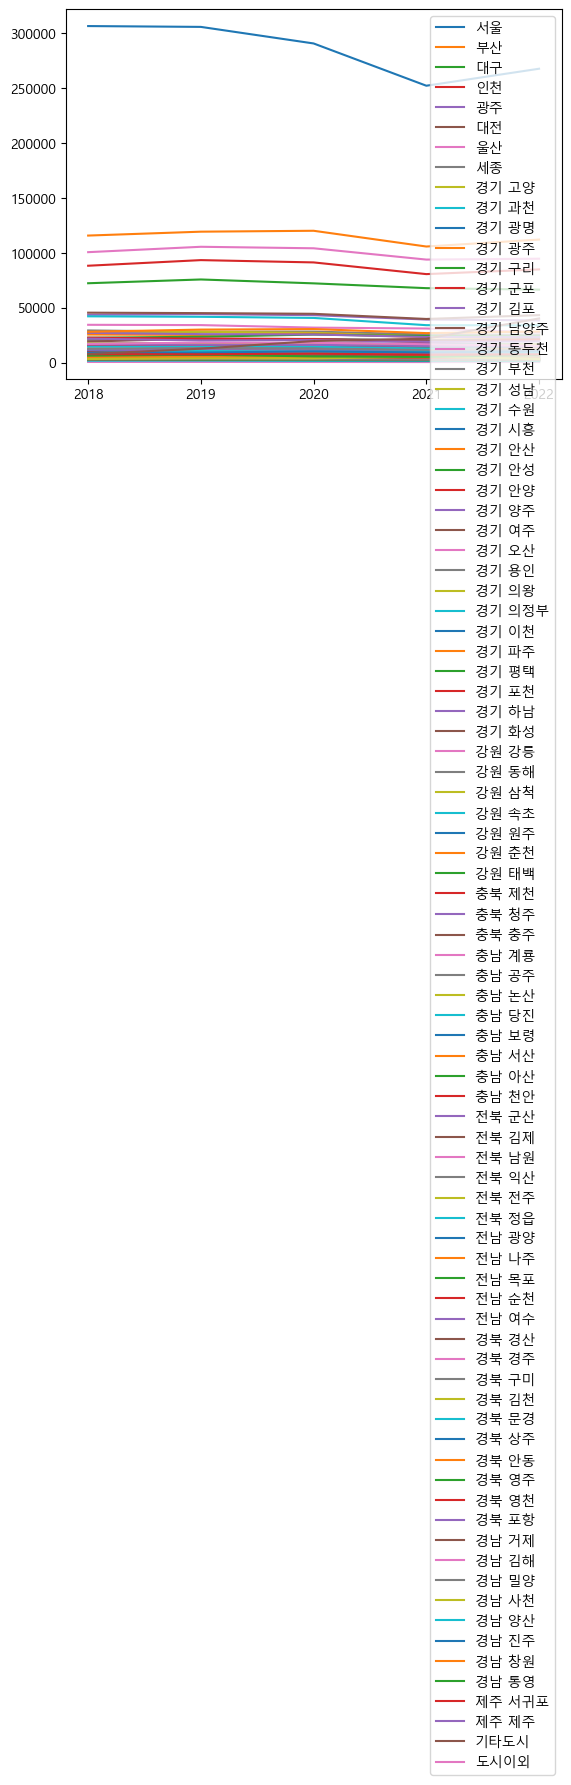

In [177]:
num_crimes.loc[decrease.loc[decrease].index].T.plot(xticks = [2018, 2019, 2020, 2021, 2022])

In [162]:
#Q4. 2022년중 마약범죄 가장 발생비율이 가장 높은 상위 10개 지역을 추출
num_crime_high = df22.iloc[:, 2:].sum()

<Axes: >

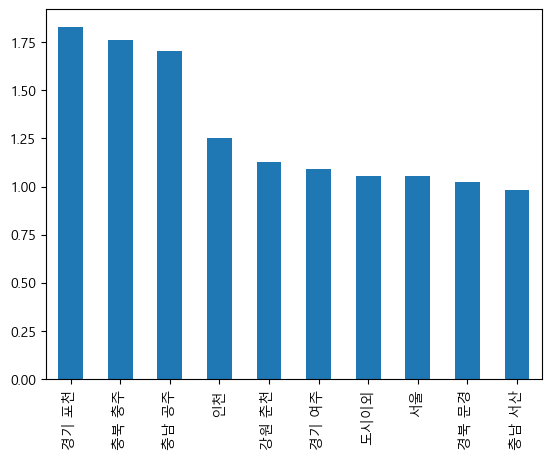

In [163]:
drug_num_crime22 = df22.loc[df22['범죄대분류'] == '마약범죄', '서울':].iloc[0]  #'서울': 의미는 서울 열 오른쪽; 즉 모든 넘버를 가져온다 
                                                                             #iloc가 아닌 loc[]를 쓴 이유는 == 마약범죄 활용위해
# 마지막 .iloc[0] 를 활용한 것은 Series로 바꿔주기 위해... 이해못함(1/8/2026)
drug_ratio_crime22 = drug_num_crime22 / num_crime22 * 100
drug_ratio_crime22.sort_values(ascending = False).iloc[:10].plot(kind = 'bar')

In [180]:
#Q5. 선거범죄 추이를 시작화하라. 2018년 부터 2022년 선거결과와 연결지어 설명; 선거는 2018, 2020, 2022년에 시행
election_data = [df18.loc[df18['범죄대분류'] == '선거범죄'].iloc[0, 2:].sum(),
                 df19.loc[df19['범죄대분류'] == '선거범죄'].iloc[0, 2:].sum(),
                 df20.loc[df20['범죄대분류'] == '선거범죄'].iloc[0, 2:].sum(),
                 df21.loc[df21['범죄대분류'] == '선거범죄'].iloc[0, 2:].sum(),
                 df22.loc[df22['범죄대분류'] == '선거범죄'].iloc[0, 2:].sum()]

<Axes: >

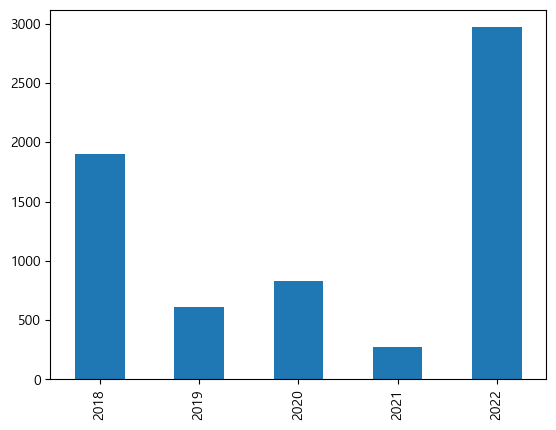

In [181]:
# Series로 바꾸준다
pd.Series(election_data, index = [2018, 2019, 2020, 2021, 2022]).plot(kind = 'bar')